In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [8]:
df =pd.read_csv("/content/drive/MyDrive/file/healthcare_dataset (1).csv")
df.head()

,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results
0,Bobby JacksOn,30,Male,B-,Cancer,2024-01-31,Matthew Smith,Sons and Miller,Blue Cross,18856.281306,328,Urgent,2024-02-02,Paracetamol,Normal
1,LesLie TErRy,62,Male,A+,Obesity,2019-08-20,Samantha Davies,Kim Inc,Medicare,33643.327287,265,Emergency,2019-08-26,Ibuprofen,Inconclusive
2,DaNnY sMitH,76,Female,A-,Obesity,2022-09-22,Tiffany Mitchell,Cook PLC,Aetna,27955.096079,205,Emergency,2022-10-07,Aspirin,Normal
3,andrEw waTtS,28,Female,O+,Diabetes,2020-11-18,Kevin Wells,"Hernandez Rogers and Vang,",Medicare,37909.782410,450,Elective,2020-12-18,Ibuprofen,Abnormal
4,adrIENNE bEll,43,Female,AB+,Cancer,2022-09-19,Kathleen Hanna,White-White,Aetna,14238.317814,458,Urgent,2022-10-09,Penicillin,Abnormal


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 55500 entries, 0 to 55499
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Name                55500 non-null  object 
 1   Age                 55500 non-null  int64  
 2   Gender              55500 non-null  object 
 3   Blood Type          55500 non-null  object 
 4   Medical Condition   55500 non-null  object 
 5   Date of Admission   55500 non-null  object 
 6   Doctor              55500 non-null  object 
 7   Hospital            55500 non-null  object 
 8   Insurance Provider  55500 non-null  object 
 9   Billing Amount      55500 non-null  float64
 10  Room Number         55500 non-null  int64  
 11  Admission Type      55500 non-null  object 
 12  Discharge Date      55500 non-null  object 
 13  Medication          55500 non-null  object 
 14  Test Results        55500 non-null  object 
dtypes: float64(1), int64(2), object(12)
memory usage: 6.4

In [19]:
df.isnull().sum()

,0
Name,0
Age,0
Gender,0
Blood Type,0
Medical Condition,0
Date of Admission,0
Doctor,0
Hospital,0
Insurance Provider,0
Billing Amount,0


In [17]:
billing = df.groupby("Medical Condition")["Billing Amount"].sum()
billing

,Billing Amount
Medical Condition,
Arthritis,2.373291e+08
Asthma,2.354598e+08
Cancer,2.321679e+08
Diabetes,2.385397e+08
Hypertension,2.357207e+08
Obesity,2.382149e+08


In [20]:
# Group by 'Medical Condition' and 'Gender' and sum 'Billing Amount'
billing_by_gender = df.groupby(['Medical Condition', 'Gender'])['Billing Amount'].sum().unstack()
billing_by_gender

Gender,Female,Male
Medical Condition,,
Arthritis,1.187439e+08,1.185853e+08
Asthma,1.155275e+08,1.199323e+08
Cancer,1.162882e+08,1.158797e+08
Diabetes,1.187540e+08,1.197858e+08
Hypertension,1.173798e+08,1.183409e+08
Obesity,1.195061e+08,1.187089e+08


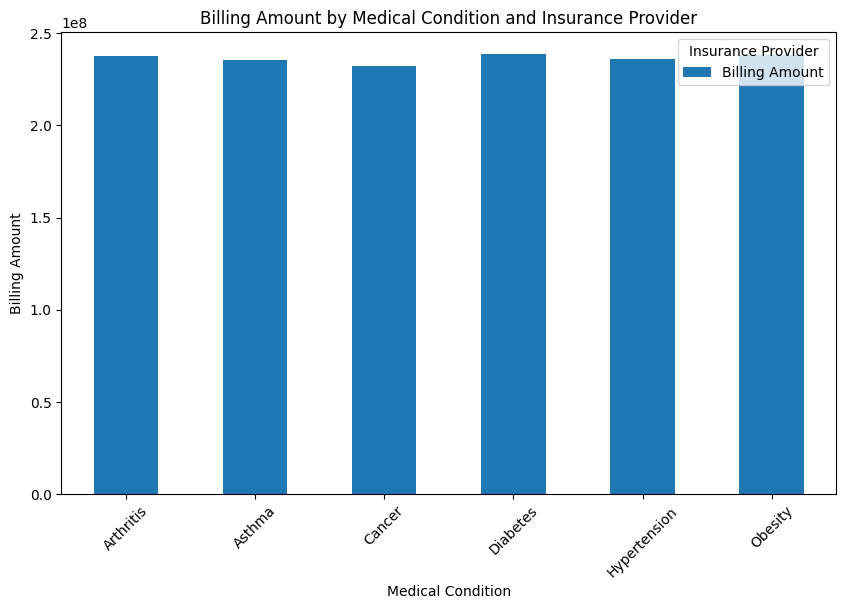

In [22]:
billing.plot(
    kind="bar",
    stacked=True,
    figsize=(10, 6)
)
plt.xlabel("Medical Condition")
plt.ylabel("Billing Amount")
plt.title("Billing Amount by Medical Condition and Insurance Provider")
plt.xticks(rotation=45)
plt.legend(title="Insurance Provider")
plt.show()

In [24]:
# Convert date columns to datetime objects
df['Date of Admission'] = pd.to_datetime(df['Date of Admission'])
df['Discharge Date'] = pd.to_datetime(df['Discharge Date'])

# Calculate Hospital_Stays in days
df['Hospital_Stays'] = (df['Discharge Date'] - df['Date of Admission']).dt.days

# Display the first few rows with the new column
display(df[['Date of Admission', 'Discharge Date', 'Hospital_Stays']].head())

,Date of Admission,Discharge Date,Hospital_Stays
0,2024-01-31,2024-02-02,2
1,2019-08-20,2019-08-26,6
2,2022-09-22,2022-10-07,15
3,2020-11-18,2020-12-18,30
4,2022-09-19,2022-10-09,20


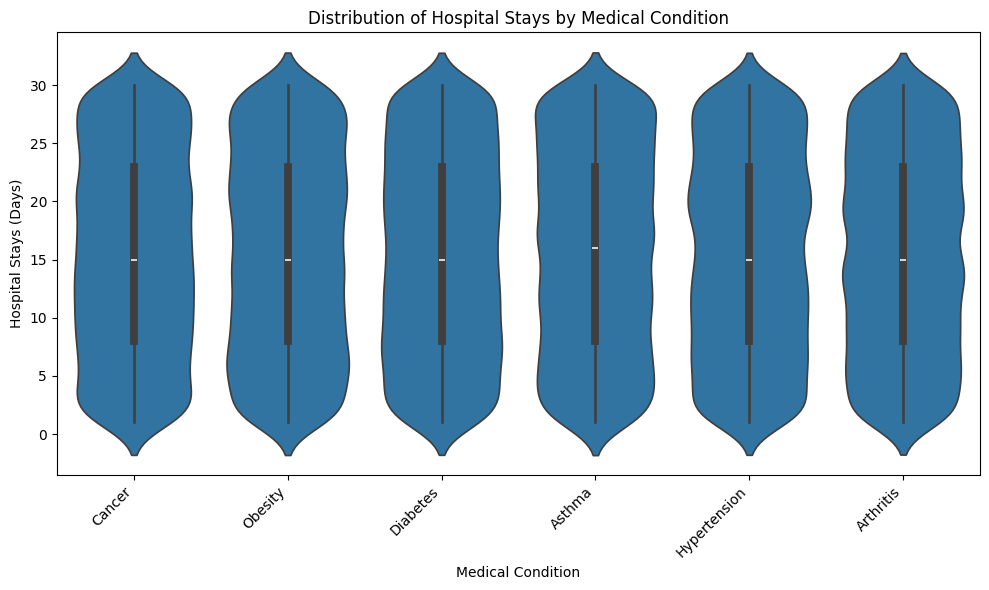

In [25]:
plt.figure(figsize=(10, 6))
sns.violinplot(
    x="Medical Condition",
    y="Hospital_Stays",
    data=df,
)
plt.title("Distribution of Hospital Stays by Medical Condition")
plt.xlabel("Medical Condition")
plt.ylabel("Hospital Stays (Days)")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()